In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import random
from collections import deque
import os

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define 1D-CNN model
class CNN1D(nn.Module):
    def __init__(self, input_length, num_classes):
        super(CNN1D, self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.25)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.25)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3)
        )
        self.flatten = nn.Flatten()
        output_length = input_length // 8
        self.dense_layers = nn.Sequential(
            nn.Linear(256 * output_length, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.flatten(x)
        x = self.dense_layers(x)
        return x

# Define ContextAwareNetwork
class ContextAwareNetwork(nn.Module):
    def __init__(self, input_size, num_layers=4, dim_feedforward=1024):
        super(ContextAwareNetwork, self).__init__()
        self.input_size = input_size
        possible_heads = [8, 4, 2, 1]
        num_heads = next(h for h in possible_heads if input_size % h == 0)
        print(f"Selected num_heads={num_heads} for input_size={input_size}")
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_size,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=0.3,  # Increased dropout
            activation='relu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Flatten(),
            nn.Linear(128 * input_size, 512),
            nn.ReLU(),
            nn.LayerNorm(512),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, input_size),
            nn.ReLU(),
            nn.LayerNorm(input_size)
        )

    def forward(self, x):
        x_flat = x.squeeze(1)
        x_transformed = self.transformer(x_flat.unsqueeze(1)).squeeze(1)
        weights = torch.sigmoid(x_transformed)
        combined = torch.stack([x_flat, weights], dim=1)
        encoded = self.encoder(combined)
        return encoded.unsqueeze(1)

# Define DQNSelector
class DQNSelector(nn.Module):
    def __init__(self, input_size):
        super(DQNSelector, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),  # Increased dropout
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),  # Increased dropout
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.network(x)

# Replay Buffer for DQN
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        state = state.squeeze().cpu()
        next_state = next_state.squeeze().cpu()
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        state, action, reward, next_state, done = zip(*random.sample(self.buffer, batch_size))
        states = torch.stack([torch.FloatTensor(s) for s in state])
        next_states = torch.stack([torch.FloatTensor(s) for s in next_state])
        return (
            states,
            torch.tensor(action, dtype=torch.long),
            torch.tensor(reward, dtype=torch.float32),
            next_states,
            torch.tensor(done, dtype=torch.float32)
        )

    def __len__(self):
        return len(self.buffer)

# DQN Agent
class DQNSelectorAgent:
    def __init__(self, input_size, device, lr=1e-4, gamma=0.95, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995, buffer_capacity=50000, batch_size=256):
        self.device = device
        self.policy_net = DQNSelector(input_size).to(device)
        self.target_net = DQNSelector(input_size).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.replay_buffer = ReplayBuffer(buffer_capacity)
        self.batch_size = batch_size
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.steps_done = 0

    def select_action(self, state):
        self.steps_done += 1
        if random.random() < self.epsilon:
            return random.randint(0, 1)
        else:
            with torch.no_grad():
                state = state.squeeze().to(self.device)
                q_values = self.policy_net(state)
                return q_values.argmax().item()

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def optimize(self):
        if len(self.replay_buffer) < self.batch_size:
            return None
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        states = states.to(self.device)
        actions = actions.to(self.device)
        rewards = rewards.to(self.device)
        next_states = next_states.to(self.device)
        dones = dones.to(self.device)
        current_q_values = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            next_actions = self.policy_net(next_states).argmax(1)
            next_q_values = self.target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze(1)
            target_q_values = rewards + (1 - dones) * self.gamma * next_q_values
        loss = nn.MSELoss()(current_q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
        self.optimizer.step()
        return loss.item()

    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

# Load and preprocess data
def load_data(dataset_path='Dataset'):
    try:
        train_df = pd.read_csv(f'{dataset_path}/oversampled_train_dataset.csv')
        val_df = pd.read_csv(f'{dataset_path}/oversampled_validation_dataset.csv')
        test_df = pd.read_csv(f'{dataset_path}/oversampled_test_dataset.csv')
        
        X_train = train_df.iloc[:, :-1].values
        y_train = train_df.iloc[:, -1].values
        X_val = val_df.iloc[:, :-1].values
        y_val = val_df.iloc[:, -1].values
        X_test = test_df.iloc[:, :-1].values
        y_test = test_df.iloc[:, -1].values
        
    except FileNotFoundError as e:
        print(f"Error: Dataset file not found: {e}")
        return None, None, None, None, None, None, None

    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train)
    y_val = label_encoder.transform(y_val)
    y_test = label_encoder.transform(y_test)
    num_classes = len(label_encoder.classes_)
    
    if num_classes != 6:
        print(f"Error: Expected 6 classes, found {num_classes} classes.")
        return None, None, None, None, None, None, None

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    X_train_tensor = torch.FloatTensor(X_train).unsqueeze(1).to(device)
    y_train_tensor = torch.LongTensor(y_train).to(device)
    X_val_tensor = torch.FloatTensor(X_val).unsqueeze(1).to(device)
    y_val_tensor = torch.LongTensor(y_val).to(device)
    X_test_tensor = torch.FloatTensor(X_test).unsqueeze(1).to(device)
    y_test_tensor = torch.LongTensor(y_test).to(device)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    class_counts = np.bincount(y_train)
    weights = 1.0 / class_counts[y_train]
    train_sampler = WeightedRandomSampler(weights, len(weights))
    train_loader = DataLoader(train_dataset, batch_size=128, sampler=train_sampler) 
    full_loader = DataLoader(train_dataset, batch_size=128, sampler=train_sampler)  
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False) 
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)  

    print("Class distribution in training data:", np.bincount(y_train))
    print("Class distribution in validation data:", np.bincount(y_val))
    print("Class distribution in test data:", np.bincount(y_test))
    print(f"Total training samples: {X_train.shape[0]}, validation samples: {X_val.shape[0]}, test samples: {X_test.shape[0]}")
    print(f"Input length: {X_train.shape[1]}")
    print(f"Full dataset size for adversarial training: {len(train_dataset)}")

    return train_loader, val_loader, test_loader, full_loader, num_classes, X_train.shape[1], class_counts

# Compute combined loss
def compute_combined_loss(outputs, labels, class_weights):
    criterion = nn.CrossEntropyLoss(weight=class_weights, reduction='none')
    per_sample_loss = criterion(outputs, labels)
    mean_loss = per_sample_loss.mean()
    return mean_loss, per_sample_loss

# Train initial CNN model
def train_initial_cnn(cnn_model, train_loader, val_loader, class_counts, epochs=500, patience=50):
    class_weights = torch.FloatTensor(1.0 / class_counts).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(cnn_model.parameters(), lr=0.0005, weight_decay=1e-4)  
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(epochs):
        cnn_model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = cnn_model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        
        epoch_loss = running_loss / len(train_loader.dataset)

        cnn_model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = cnn_model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = val_loss / len(val_loader.dataset)
        val_accuracy = correct / total
        print(f"Initial CNN Epoch {epoch+1}/{epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = cnn_model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                cnn_model.load_state_dict(best_model_state)
                break
        
        scheduler.step()
    
    return cnn_model

# Evaluate model
def evaluate_model(model, test_loader, class_weights, context_model=None, dqn_agent=None, threshold=None):
    model.eval()
    y_true = []
    y_pred = []
    running_loss = 0.0
    total_samples = 0
    softmax = nn.Softmax(dim=1)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            batch_size = inputs.size(0)
            total_samples += batch_size

            if context_model and dqn_agent and threshold is not None:
                cnn_outputs = model(inputs)
                probs = softmax(cnn_outputs)
                one_hot = torch.zeros_like(probs).to(device)
                one_hot.scatter_(1, labels.unsqueeze(1), 1.0)
                
                #indices = [i for i in range(batch_size) if actions_batch[i] == 1]
                #if indices:
                encoded_inputs = context_model(inputs)
                outputs = model(encoded_inputs)
                
                _, predicted = torch.max(outputs, 1)
                final_loss = criterion(outputs, labels)
                running_loss += final_loss.item() * batch_size
            else:
                outputs = model(inputs)
                final_loss = criterion(outputs, labels)
                running_loss += final_loss.item() * batch_size
                _, predicted = torch.max(outputs, 1)
            
            y_pred.extend(predicted.cpu().numpy())
            y_true.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    test_loss = running_loss / total_samples
    
    return {
        'Test Loss': test_loss,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

def compute_reward(action, cnn_pred, weighted_pred, label):
    if action == 1:
        if weighted_pred != label and cnn_pred != label:
            reward = 3.0
            return reward
        elif weighted_pred == label and cnn_pred != label:
            reward = 2.0  # Penalize more strongly
            return reward
        elif weighted_pred != label and cnn_pred == label:
            reward = -2.0  # Penalize more strongly for unnecessary use
            return reward
        else:
            reward = 0.0
            return reward
    else:
        reward = 1.5 if cnn_pred == label else -1.0  # Slightly higher reward for correct non-use
        return reward

# Train adversarial system using full dataset
def train_adversarial_system(cnn_model, dqn_agent, context_model, full_loader, val_loader, class_counts, input_length, num_classes, fine_tune_epochs=500, patience=50):
    class_weights = torch.FloatTensor(1.0 / class_counts).to(device)
    cnn_criterion = nn.CrossEntropyLoss(weight=class_weights)
    context_optimizer = optim.Adam(context_model.parameters(), lr=5e-4, weight_decay=1e-4)  # Lowered LR
    context_scheduler = lr_scheduler.CosineAnnealingLR(context_optimizer, T_max=100)  # Increased T_max
    best_val_accuracy = 0.0
    epochs_no_improve = 0
    softmax = nn.Softmax(dim=1)
    best_context_state = None
    best_dqn_state = None

    # Pre-train ContextAwareNetwork
    print("Pre-training ContextAwareNetwork...")
    for _ in range(20):  # Increased pre-training loops
        context_model.train()
        for inputs, labels in full_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            context_optimizer.zero_grad()
            encoded_inputs = context_model(inputs)
            cnn_outputs_weighted = cnn_model(encoded_inputs)
            context_loss = cnn_criterion(cnn_outputs_weighted, labels)
            context_loss.backward()
            context_optimizer.step()
        context_scheduler.step()

    print("Starting adversarial training on full dataset...")
    for epoch in range(fine_tune_epochs):
        cnn_model.eval()  # CNN is not fine-tuned, only used for predictions
        context_model.train()
        dqn_agent.policy_net.train()
        running_context_loss = 0.0
        running_dqn_loss = 0.0
        dqn_loss_count = 0
        total_samples = 0
        context_updated_samples = 0
        rewards = []
        actions = []
        context_updated = False

        for batch_idx, (inputs, labels) in enumerate(full_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            batch_size = inputs.size(0)
            total_samples += batch_size

            # Compute CNN outputs and state for DQN
            with torch.no_grad():
                cnn_outputs = cnn_model(inputs).detach()
                probs = softmax(cnn_outputs)
                _, cnn_pred = torch.max(cnn_outputs, 1)
                max_prob, _ = torch.max(probs, dim=1, keepdim=True)
                uncertainty = 1 - max_prob

            features = inputs.squeeze(1).detach()
            one_hot = torch.zeros_like(probs).to(device)
            one_hot.scatter_(1, labels.unsqueeze(1), 1.0)
            distances = torch.abs(probs - one_hot)
            per_sample_loss = distances.mean(dim=1, keepdim=True)
            per_sample_loss = torch.clamp(per_sample_loss, max=1.0)
            state = torch.cat([features, uncertainty], dim=1).detach()
            actions_batch = [dqn_agent.select_action(state[i:i+1]) for i in range(batch_size)]
            actions.extend(actions_batch)

            # Update ContextAwareNetwork for all samples
            if batch_size > 0:
                if batch_size == 1:
                    inputs = inputs.repeat(2, 1, 1)
                    labels = labels.repeat(2)
                    batch_size = 2
                    
                context_optimizer.zero_grad()
                encoded_inputs = context_model(inputs)
                cnn_outputs_weighted = cnn_model(encoded_inputs)
                context_loss = cnn_criterion(cnn_outputs_weighted, labels)
                orig_cnn_loss = cnn_criterion(cnn_model(inputs), labels)
                epsilon = 1e-8
                loss_ratio = orig_cnn_loss / (context_loss + epsilon)
                total_context_loss = 0.8*context_loss + 0.2 / (1 + loss_ratio)  # Adjusted weight
                total_context_loss = torch.clamp(total_context_loss, max=1.0)
                total_context_loss.backward()
                context_optimizer.step()
                running_context_loss += total_context_loss.item() * batch_size
                context_updated = True
                context_updated_samples += batch_size

            # Compute rewards and update DQN for all samples
            reward = []
            with torch.no_grad():
                encoded_inputs = context_model(inputs).detach()
                cnn_outputs_weighted = cnn_model(encoded_inputs).detach()
                _, weighted_pred = torch.max(cnn_outputs_weighted, 1)

            for i in range(batch_size):
                r = compute_reward(actions_batch[i], cnn_pred[i], weighted_pred[i], labels[i])
                reward.append(r)
                dqn_agent.replay_buffer.push(state[i:i+1], actions_batch[i], r, state[i:i+1], 1.0)
            rewards.extend(reward)
            dqn_loss = dqn_agent.optimize()
            if dqn_loss is not None:
                running_dqn_loss += dqn_loss
                dqn_loss_count += 1

        if context_updated:
            context_scheduler.step()

        dqn_agent.update_epsilon()
        if epoch % 5 == 0:
            dqn_agent.update_target_network()

        print(f"Adversarial Epoch {epoch+1}/{fine_tune_epochs}:")
        print(f"  Context Loss: {running_context_loss / max(context_updated_samples, 1):.4f}")
        print(f"  DQN Loss: {running_dqn_loss / max(dqn_loss_count, 1):.4f}")
        print(f"  Context Updated Samples: {context_updated_samples}")
        print(f"  Average Reward: {np.mean(rewards) if rewards else 0.0:.4f}")
        print(f"  Action Distribution: {np.bincount(actions, minlength=2) if actions else [0, 0]}")

        # Validation
        val_results = evaluate_model(cnn_model, val_loader, class_weights, context_model, dqn_agent, threshold=0.5)
        print(f"Validation Results at Epoch {epoch+1}:")
        print(f"  Val Loss: {val_results['Test Loss']:.4f}")
        print(f"  Val Accuracy: {val_results['Accuracy']:.4f}")
        print(f"  Val Precision: {val_results['Precision']:.4f}")
        print(f"  Val Recall: {val_results['Recall']:.4f}")
        print(f"  Val F1 Score: {val_results['F1 Score']:.4f}")

        if val_results['Accuracy'] > best_val_accuracy:
            best_val_accuracy = val_results['Accuracy']
            epochs_no_improve = 0
            best_context_state = context_model.state_dict()
            best_dqn_state = dqn_agent.policy_net.state_dict()
            print("Updated best adversarial model states")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

    # Save best Context and DQN models separately
    if best_context_state is not None:
        torch.save({
            'context_model_state_dict': best_context_state,
            'input_length': input_length,
            'num_classes': num_classes
        }, 'Models/adversarial_best_context.pth')
        print("Saved best adversarial Context model")
    if best_dqn_state is not None:
        torch.save({
            'dqn_policy_net_state_dict': best_dqn_state,
            'input_length': input_length,
            'num_classes': num_classes,
            'replay_buffer': list(dqn_agent.replay_buffer.buffer)  # Save the deque buffer as list
        }, 'Models/adversarial_best_dqn.pth')
        print("Saved best adversarial DQN model with replay buffer")

    return cnn_model, dqn_agent, context_model

# Main execution
def main():
    base_epoch = 200
    base_patience = 30
    adver_epoch = 300
    adver_patience = 30
    
    # Load data
    train_loader, val_loader, test_loader, full_loader, num_classes, input_length, class_counts = load_data()
    if train_loader is None or full_loader is None:
        print("Failed to load data. Exiting.")
        return

    # Train and evaluate initial CNN
    cnn_model = CNN1D(input_length, num_classes).to(device)
    cnn_model = train_initial_cnn(cnn_model, train_loader, val_loader, class_counts, base_epoch, base_patience)
    
    if not os.path.exists('Models'):
        os.makedirs('Models')
    
    torch.save({
        'model_state_dict': cnn_model.state_dict(),
        'input_length': input_length,
        'num_classes': num_classes
    }, 'Models/initial_cnn_model.pth')
    print("Saved initial CNN model")

    class_weights = torch.FloatTensor(1.0 / class_counts).to(device)
    initial_results = evaluate_model(cnn_model, test_loader, class_weights)
    print("\nInitial CNN Test Results:")
    print(f"  Test Loss: {initial_results['Test Loss']:.4f}")
    print(f"  Accuracy: {initial_results['Accuracy']:.4f}")
    print(f"  Precision: {initial_results['Precision']:.4f}")
    print(f"  Recall: {initial_results['Recall']:.4f}")
    print(f"  F1 Score: {initial_results['F1 Score']:.4f}")

    # Initialize DQN and Context models
    dqn_agent = DQNSelectorAgent(input_length + 1, device)
    context_model = ContextAwareNetwork(input_length).to(device)

    # Train adversarial system using full_loader (full dataset)
    cnn_model, dqn_agent, context_model = train_adversarial_system(
        cnn_model, dqn_agent, context_model, full_loader, val_loader, class_counts, input_length, num_classes,
        adver_epoch, adver_patience
    )

    # Evaluate adversarial system
    adversarial_results = evaluate_model(cnn_model, test_loader, class_weights, context_model, dqn_agent, threshold=0.5)
    print("\nAdversarial System Test Results:")
    print(f"  Test Loss: {adversarial_results['Test Loss']:.4f}")
    print(f"  Accuracy: {adversarial_results['Accuracy']:.4f}")
    print(f"  Precision: {adversarial_results['Precision']:.4f}")
    print(f"  Recall: {adversarial_results['Recall']:.4f}")
    print(f"  F1 Score: {adversarial_results['F1 Score']:.4f}")



Using device: cuda


In [ ]:
if __name__ == "__main__":
    main()

## 1D CNN or base model analysis on Perturbation Attacks

Using device: cuda
Loading perturbation level datasets...
Loaded perturb_level 0: 1073 samples, 100 features
Loaded perturb_level 1: 1073 samples, 100 features
Loaded perturb_level 3: 1073 samples, 100 features
Loaded perturb_level 5: 1073 samples, 100 features
Loaded perturb_level 7: 1073 samples, 100 features
Loaded perturb_level 10: 1073 samples, 100 features
Loaded perturb_level 12: 1073 samples, 100 features
Loaded perturb_level 15: 1073 samples, 100 features
Loaded perturb_level 17: 1073 samples, 100 features
Loaded perturb_level 20: 1073 samples, 100 features

Successfully loaded 10 perturbation levels
Input length: 100
Number of classes: 6

Loaded initial CNN model

EVALUATING BASE CNN MODEL ON ALL PERTURBATION LEVELS

Evaluating Perturbation Level: 0
--------------------------------------------------
Test Loss:     0.9052
Accuracy:      0.7633
Precision:     0.7650
Recall:        0.7633
F1 Score:      0.7639
Samples:       1073

Evaluating Perturbation Level: 1
---------------

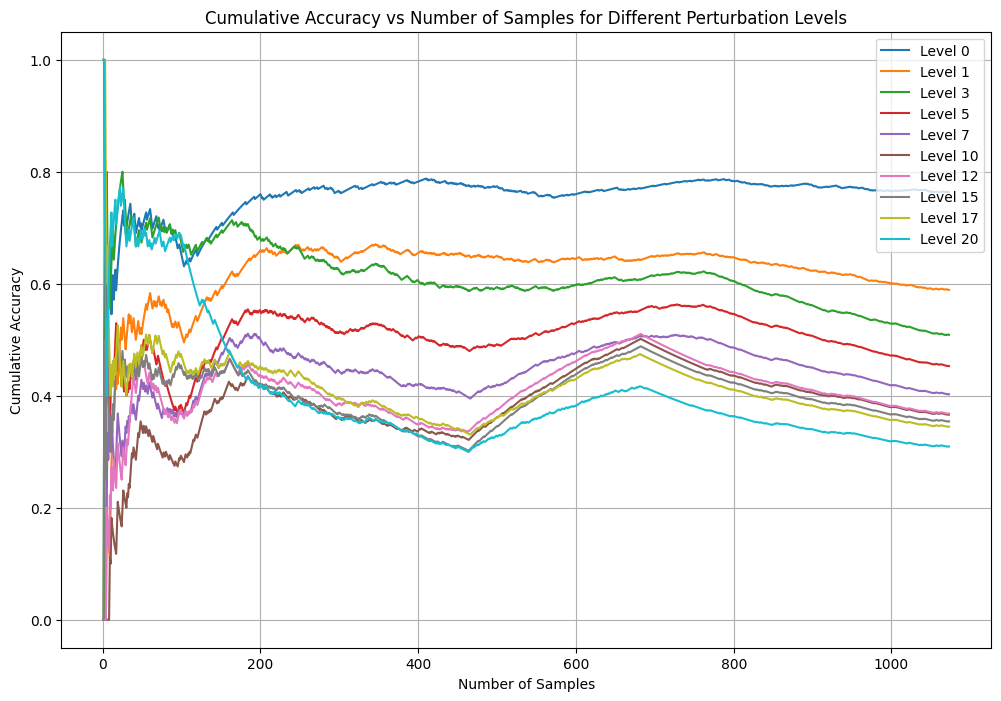


Cumulative accuracy plot saved to: Results/cumulative_accuracy_plot.png


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import os
import matplotlib.pyplot as plt

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define 1D-CNN model (same as original)
class CNN1D(nn.Module):
    def __init__(self, input_length, num_classes):
        super(CNN1D, self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.25)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.25)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3)
        )
        self.flatten = nn.Flatten()
        output_length = input_length // 8
        self.dense_layers = nn.Sequential(
            nn.Linear(256 * output_length, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.flatten(x)
        x = self.dense_layers(x)
        return x

# Load perturbation level data
def load_perturbation_data(base_path='Dataset/AdvBurst_FTSC-IAT', test_perturb_levels=[0, 1, 3, 5, 7, 10, 12, 15, 17, 20]):
    """
    Load all perturbation level datasets and return a dictionary of loaders
    """
    if not os.path.exists(base_path):
        print(f"Error: Data directory '{base_path}' not found.")
        return None

    all_results = {}
    label_encoder = None
    scaler = None
    num_classes = None
    input_length = None

    print("Loading perturbation level datasets...")
    
    for perturb_level in test_perturb_levels:
        try:
            # Load the specific perturbation level dataset
            df = pd.read_csv(f'{base_path}/AdvBurstTrainedBurst_size_{perturb_level}_Step_2000.csv')
            X_test = df.iloc[:, :-1].values
            y_test = df.iloc[:, -1].values
            
            print(f"Loaded perturb_level {perturb_level}: {X_test.shape[0]} samples, {X_test.shape[1]} features")
            
            # First time: fit encoder and scaler
            if label_encoder is None:
                label_encoder = LabelEncoder()
                y_test_encoded = label_encoder.fit_transform(y_test)
                num_classes = len(label_encoder.classes_)
                
                if num_classes != 6:
                    print(f"Error: Expected 6 classes, found {num_classes} classes.")
                    return None
                
                scaler = StandardScaler()
                X_test_scaled = scaler.fit_transform(X_test)
                input_length = X_test.shape[1]
            else:
                # Subsequent times: transform only
                y_test_encoded = label_encoder.transform(y_test)
                X_test_scaled = scaler.transform(X_test)
            
            # Convert to tensors
            X_test_tensor = torch.FloatTensor(X_test_scaled).unsqueeze(1).to(device)
            y_test_tensor = torch.LongTensor(y_test_encoded).to(device)
            
            # Create dataset and loader
            test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
            test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
            
            all_results[perturb_level] = {
                'loader': test_loader,
                'num_samples': X_test.shape[0]
            }
            
        except FileNotFoundError:
            print(f"Warning: File not found for perturb_level {perturb_level}, skipping...")
            continue
        except Exception as e:
            print(f"Error loading perturb_level {perturb_level}: {e}")
            continue

    print(f"\nSuccessfully loaded {len(all_results)} perturbation levels")
    print(f"Input length: {input_length}")
    print(f"Number of classes: {num_classes}")
    
    return all_results, num_classes, input_length, label_encoder, scaler

# Evaluate model on a specific perturbation level dataset
def evaluate_model_on_level(model, test_loader, class_weights):
    model.eval()
    y_true = []
    y_pred = []
    corrects = []  # List to store 1/0 for each sample
    running_loss = 0.0
    total_samples = 0
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            batch_size = inputs.size(0)
            total_samples += batch_size

            outputs = model(inputs)
            final_loss = criterion(outputs, labels)
            running_loss += final_loss.item() * batch_size
            _, predicted = torch.max(outputs, 1)

            # Collect per-sample correct (1 or 0)
            batch_corrects = (predicted == labels).cpu().numpy().astype(int).tolist()
            corrects.extend(batch_corrects)

            y_pred.extend(predicted.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    test_loss = running_loss / total_samples

    # Calculate cumulative accuracy
    corrects_np = np.array(corrects)
    cumulative_acc = np.cumsum(corrects_np) / np.arange(1, len(corrects_np) + 1)
    
    return {
        'Test Loss': test_loss,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }, cumulative_acc

# Main function to load model and evaluate all perturbation levels
def main():
    # Load all perturbation level datasets
    all_data, num_classes, input_length, _, _ = load_perturbation_data()
    if all_data is None:
        print("Failed to load perturbation data. Exiting.")
        return

    # Load the initial CNN model
    cnn_model = CNN1D(input_length, num_classes).to(device)
    try:
        checkpoint = torch.load('Models/initial_cnn_model.pth', map_location=device)
        cnn_model.load_state_dict(checkpoint['model_state_dict'])
        print("\nLoaded initial CNN model")
    except FileNotFoundError:
        print("Error: initial_cnn_model.pth not found in Models/ directory")
        return

    # Assuming balanced classes (6 classes)
    class_counts = np.array([1] * num_classes)
    class_weights = torch.FloatTensor(1.0 / class_counts).to(device)

    # Evaluate on all perturbation levels
    print("\n" + "="*80)
    print("EVALUATING BASE CNN MODEL ON ALL PERTURBATION LEVELS")
    print("="*80)
    
    results_table = []
    cumulative_dict = {}  # To store cumulative acc for each level
    max_samples = 0  # To find the max number of samples across levels
    
    for perturb_level, data_info in sorted(all_data.items()):
        print(f"\nEvaluating Perturbation Level: {perturb_level}")
        print("-" * 50)
        
        results, cumulative_acc = evaluate_model_on_level(
            cnn_model, 
            data_info['loader'], 
            class_weights
        )
        
        # Store cumulative
        cumulative_dict[perturb_level] = cumulative_acc
        if len(cumulative_acc) > max_samples:
            max_samples = len(cumulative_acc)
        
        # Store summary results
        results_table.append({
            'Perturbation Level': perturb_level,
            'Test Loss': f"{results['Test Loss']:.4f}",
            'Accuracy': f"{results['Accuracy']:.4f}",
            'Precision': f"{results['Precision']:.4f}",
            'Recall': f"{results['Recall']:.4f}",
            'F1 Score': f"{results['F1 Score']:.4f}",
            'Samples': data_info['num_samples']
        })
        
        # Print results
        print(f"Test Loss:     {results['Test Loss']:.4f}")
        print(f"Accuracy:      {results['Accuracy']:.4f}")
        print(f"Precision:     {results['Precision']:.4f}")
        print(f"Recall:        {results['Recall']:.4f}")
        print(f"F1 Score:      {results['F1 Score']:.4f}")
        print(f"Samples:       {data_info['num_samples']}")

    # Display summary table
    print("\n" + "="*80)
    print("SUMMARY TABLE - BASE CNN MODEL PERFORMANCE")
    print("="*80)
    
    df_results = pd.DataFrame(results_table)
    print(df_results.to_string(index=False))
    
    # Save summary results to CSV
    if not os.path.exists('Results'):
        os.makedirs('Results')
    
    df_results.to_csv('Results/base_model_perturbation_results.csv', index=False)
    print(f"\nResults saved to: Results/base_model_perturbation_results.csv")

    # Now, create cumulative accuracy DataFrame
    # Assuming all levels have the same number of samples, but handle if not
    columns = ['perturb_level'] + [f'cum_acc_{i}' for i in range(1, max_samples + 1)]
    cum_rows = []
    for perturb_level in sorted(cumulative_dict.keys()):
        cum_acc = cumulative_dict[perturb_level]
        # Pad with NaN if shorter
        padded_cum = np.pad(cum_acc, (0, max_samples - len(cum_acc)), constant_values=np.nan)
        row = [perturb_level] + list(padded_cum)
        cum_rows.append(row)
    
    df_cum = pd.DataFrame(cum_rows, columns=columns)
    df_cum.to_csv('Results/cumulative_accuracy.csv', index=False)
    print(f"\nCumulative accuracy saved to: Results/cumulative_accuracy.csv")

    # Plot cumulative accuracy
    plt.figure(figsize=(12, 8))
    for perturb_level, cum_acc in cumulative_dict.items():
        plt.plot(range(1, len(cum_acc) + 1), cum_acc, label=f'Level {perturb_level}')
    plt.xlabel('Number of Samples')
    plt.ylabel('Cumulative Accuracy')
    plt.title('Cumulative Accuracy vs Number of Samples for Different Perturbation Levels')
    plt.legend()
    plt.grid(True)
    plt.savefig('Results/cumulative_accuracy_plot.png')
    plt.show()
    print("\nCumulative accuracy plot saved to: Results/cumulative_accuracy_plot.png")

if __name__ == "__main__":
    main()